# Installing

In [7]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
pip install -U scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 5.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 2.2 MB/s eta 0:00:46
   ---------------------------------------- 1.0/101.7 MB 2.6 MB/s eta 0:00:39
    --------------------------------------- 1.8/101.7 MB 2.9 MB/s eta 0:00:35
    --------------------------------------- 2.4/101.7 MB 2.8 MB/s eta 0:00:36
   - -------------------------------------- 3.1/101.7 MB 2.9 MB/s eta 0:00:34
   - -------------------------------------- 3.9/101.7 MB 3.0 MB/s eta 0:00:33
   - -------------------------------------- 4.7/101.7 MB 3.1 MB/s eta 0:00:32
   -- ------------------------------------- 5.5/101.7 MB 3.2 MB/s eta 0:00:30
   -- ------------------------------------- 6.6/101.7 MB 3.4 MB/s eta 0:00:29
   -- ------------------------------------- 7.3/101.7 MB 3.4 MB/s eta 0:00:28
   -- -


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Importing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

import seaborn as sb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

df = pd.read_csv("Clean_Dataset.csv")
df.head()



,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


# Correlation

(300153, 11)


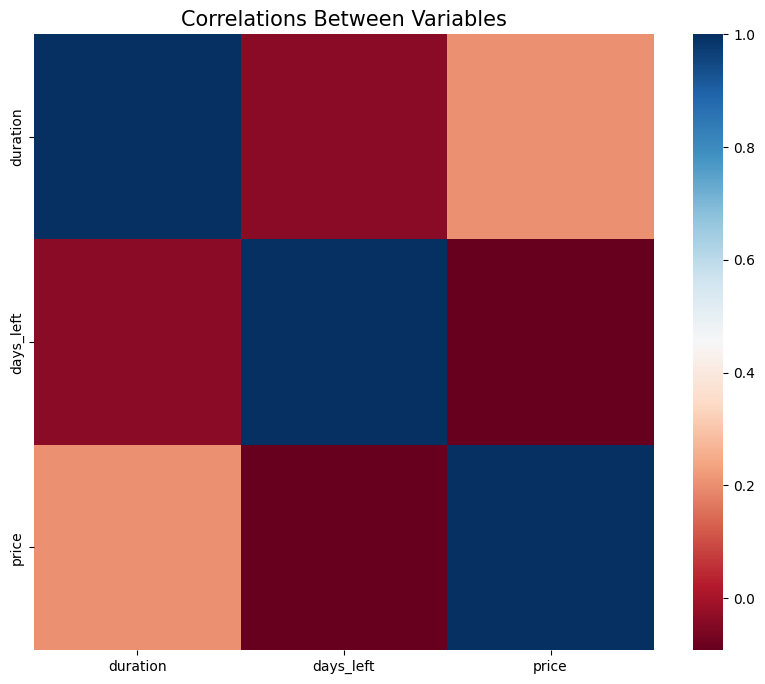

In [2]:
print(df.shape)
plt.figure(figsize=(10,8))
sb.heatmap(df.corr(numeric_only=True), cmap="RdBu")
plt.title("Correlations Between Variables", size=15)
plt.show()

# Missing values

In [3]:
print("Missing Values by Column")
print("-"*30)
print(df.isna().sum())
print("-"*30)
print("TOTAL MISSING VALUES:",df.isna().sum().sum())

Missing Values by Column
------------------------------
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64
------------------------------
TOTAL MISSING VALUES: 0


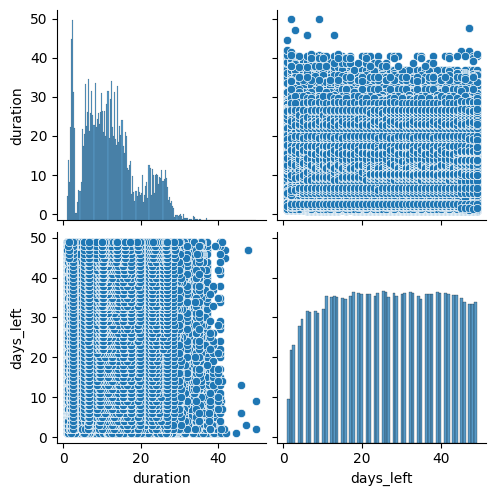

In [4]:
important_num_cols = ['duration', 'days_left']

cat_cols = [
    'airline',
    'source_city',
    'departure_time',
    'stops',
    'arrival_time',
    'destination_city',
    'class'
]

important_cols = important_num_cols + cat_cols



sb.pairplot(df[important_num_cols])

# Splitting data

In [5]:
X = df.drop(["price", "flight"], axis=1)
y = df["price"]

In [6]:
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Scaling

In [7]:
scaler = StandardScaler()
X[important_num_cols] = scaler.fit_transform(X[important_num_cols])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=121)

In [9]:
def rmse_cv(model):
    rmse = np.sqrt(-cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=5)).mean()
    return rmse
    

def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mean_squared_error(y, predictions))
    r_squared = r2_score(y, predictions)
    return mae, mse, rmse, r_squared

# Testing

In [10]:
models = pd.DataFrame(columns=["Model","MAE","MSE","RMSE","R2 Score","RMSE (Cross-Validation)"])

In [32]:
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
predictions = rf.predict(X_test)
predictions

array([49814.69027437,  4710.74064837, 52966.54732206, ...,
        9815.08037823, 21025.56670068, 52937.54800569], shape=(60031,))

In [33]:
i = 0

row = X_test.iloc[[i]]

predicted = rf.predict(row)[0]
actual = y_test.iloc[i]

print("Actual Price:", actual)
print("Predicted Price:", predicted)
print("Difference:", predicted - actual)

Actual Price: 49613
Predicted Price: 49814.69027437202
Difference: 201.6902743720202


In [34]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)
rmse_cross_val = rmse_cv(rf)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = {"Model": "LinearRegression","MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r_squared, "RMSE (Cross-Validation)": rmse_cross_val}
models.loc[len(models)] = new_row

MAE: 1789.4054574255997
MSE: 11817032.602375118
RMSE: 3437.591104592738
R2 Score: 0.9770417089645783
------------------------------
RMSE Cross-Validation: 5048.510988490454


# Saving model

In [30]:
import joblib

In [35]:
joblib.dump({
    "model": rf,
    "scaler": scaler,
    "columns": X.columns.tolist()
}, "airfare_predictor.pkl")

['airfare_predictor.pkl']